# K-Nearest Neighbors: Native XAI via Permutation Importance Only

This notebook covers **KNN** (`sklearn.neighbors.KNeighborsClassifier`, `n_neighbors=25`) from the
16-model FinSentImpact zoo. KNN is the one model in the zoo for which the official XAI pipeline
**deliberately excludes KernelSHAP, LIME, and (in the paired agnostic-methods run) even permutation
and ALE**: see `results/metrics/xai_by_model_agnostic.json`, where every KNN row is `status: "N/A"`
with an explicit `reason`. We surface that limitation here rather than silently working around it,
and then compute a standalone, live permutation-importance run ourselves (a much cheaper operation
than KernelSHAP/LIME because it needs only `n_repeats` full re-scorings, not thousands of individual
perturbed-instance predictions).

As in the companion notebooks, real predictive signal on actual returns is validated near-zero on
purpose (max |MCC| ~0.011 across the whole 16-model zoo) -- the point is to check whether the
explanation method (here, permutation importance alone) still correctly recovers the injected
synthetic ground-truth signal.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, roc_auc_score
from sklearn.inspection import permutation_importance

RESULTS = Path('../results')
SEED = 42
np.random.seed(SEED)

PRICE_FEATS = ["ret_lag1","ret_lag2","ret_lag3","ret_lag5","vol_roll5","vol_roll20",
               "rsi14","ma_gap20","hl_range","co_ret","logvol","vol_z20"]
SENT_FEATS = ["fb_score","fb_pos","fb_neg","lm_score","news_count","has_news",
              "fb_roll3","fb_roll5","news_roll5","fb_chg"]
GT_FEATS = ["gt_noise","gt_signal","gt_signal_nl","gt_signal_weak",
            "gt_redundant_copy","gt_redundant_partial"]

panel = pd.read_parquet(RESULTS / 'panel.parquet')
print(f"panel: {panel.shape[0]:,} rows x {panel.shape[1]} cols, "
      f"{panel['Symbol'].nunique()} tickers, {panel['Date'].min().date()} to {panel['Date'].max().date()}")

panel: 127,609 rows x 49 cols, 57 tickers, 2015-02-03 to 2023-12-27


## Why KNN is excluded from KernelSHAP/LIME/permutation in the official agnostic-methods run

This is a real, reported architectural/scale limitation, not an oversight. Quoting
`results/metrics/xai_by_model_agnostic.json` directly:

In [2]:
with open(RESULTS / 'metrics' / 'xai_by_model_agnostic.json') as f:
    agnostic = json.load(f)

knn_rows = [r for r in agnostic if r['model'] == 'KNN']
print(f"All {len(knn_rows)} KNN rows in xai_by_model_agnostic.json:\n")
for r in knn_rows:
    print(f"method: {r['method']:<18s} status: {r['status']:<5s} reason: {r['reason']}")

print("\nIn plain terms: KNN's predict / predict_proba cost is O(n_train) per call (it scans, or "
      "uses a tree/ball structure over, the full training set for every single prediction). "
      "KernelSHAP needs thousands of such calls per explained instance (one per sampled feature "
      "coalition), and LIME needs ~5000 perturbed-sample calls per explained instance -- both "
      "become prohibitively slow at this panel's ~100k-row training scale. The official agnostic "
      "run additionally drops KNN from permutation/block_permutation/ALE there too, purely to keep "
      "an identical 5-model comparison set (Logistic/RandomForest/XGBoost/EBM/SVM) across every "
      "method in that particular table -- not because permutation importance is intractable for "
      "KNN. We compute permutation importance for KNN live below, standalone, since it only needs "
      "n_repeats full re-scorings of the (already-fitted) model, not per-instance coalition "
      "sampling.")

All 5 KNN rows in xai_by_model_agnostic.json:

method: kernelshap         status: N/A   reason: KNN predict_proba is O(n_train) per call; KernelSHAP needs thousands of such calls, prohibitively slow at this data scale.
method: lime               status: N/A   reason: same as kernelshap -- LIME perturbs ~5000 samples per explained instance, each needing a KNN predict_proba call.
method: permutation        status: N/A   reason: excluded to keep an identical 5-model set across all agnostic methods in this run (see function docstring).
method: block_permutation  status: N/A   reason: same as permutation.
method: ale                status: N/A   reason: same as permutation.

In plain terms: KNN's predict / predict_proba cost is O(n_train) per call (it scans, or uses a tree/ball structure over, the full training set for every single prediction). KernelSHAP needs thousands of such calls per explained instance (one per sampled feature coalition), and LIME needs ~5000 perturbed-sample calls per

## Walk-forward protocol and subsampling

Expanding window, 10-day embargo, demo fold = 2023. Mirroring the official pipeline: SVC/KNN training
is subsampled to 9000 rows whenever the expanding-window train set exceeds that cap, since brute-force
KNN distance computation also scales poorly with `n_train`.

In [3]:
def make_fold(df, feature_cols, target_col, fold_year, embargo_days=10):
    test_start = pd.Timestamp(f'{fold_year}-01-01')
    train_cutoff = test_start - pd.Timedelta(days=embargo_days)
    train = df[df['Date'] < train_cutoff]
    test = df[df['Date'].dt.year == fold_year]
    scaler = StandardScaler().fit(train[feature_cols])
    Xtr = scaler.transform(train[feature_cols])
    Xte = scaler.transform(test[feature_cols])
    ytr = train[target_col].values
    yte = test[target_col].values
    return Xtr, Xte, ytr, yte

def subsample(Xtr, ytr, cap=9000, seed=SEED):
    if len(Xtr) > cap:
        rng = np.random.RandomState(seed)
        subsample_idx = rng.choice(len(Xtr), cap, replace=False)
        return Xtr[subsample_idx], ytr[subsample_idx]
    return Xtr, ytr

FOLD_YEAR = 2023
FEATS_OFFICIAL = PRICE_FEATS + SENT_FEATS

Xtr, Xte, ytr, yte = make_fold(panel, FEATS_OFFICIAL, 'dir_next', FOLD_YEAR)
Xtr_s, ytr_s = subsample(Xtr, ytr)
print(f"fold {FOLD_YEAR}: train={len(Xtr):,} rows (pre-subsample) -> {len(Xtr_s):,} rows "
      f"(post-subsample, cap=9000), test={len(Xte):,} rows, {len(FEATS_OFFICIAL)} features "
      "(price+sentiment)")

fold 2023: train=113,131 rows (pre-subsample) -> 9,000 rows (post-subsample, cap=9000), test=14,136 rows, 22 features (price+sentiment)


In [4]:
t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=25, n_jobs=-1)
knn.fit(Xtr_s, ytr_s)
fit_s = time.time() - t0

t0 = time.time()
pred = knn.predict(Xte)
proba = knn.predict_proba(Xte)[:, 1]
predict_s = time.time() - t0

acc = accuracy_score(yte, pred)
f1 = f1_score(yte, pred)
mcc = matthews_corrcoef(yte, pred)
auc = roc_auc_score(yte, proba)

print(f"KNN fit time (9000-row subsample): {fit_s:.2f}s")
print(f"KNN predict time on {len(Xte):,} test rows: {predict_s:.2f}s "
      f"({predict_s / len(Xte) * 1000:.2f} ms/row -- this per-call cost is exactly why "
      "KernelSHAP/LIME are excluded: they would need thousands of calls like this per explained "
      "instance)")
print(f"Live demo fold {FOLD_YEAR} (price+sentiment): Acc={acc:.4f} F1={f1:.4f} MCC={mcc:.4f} AUC={auc:.4f}")

KNN fit time (9000-row subsample): 0.00s
KNN predict time on 14,136 test rows: 0.35s (0.02 ms/row -- this per-call cost is exactly why KernelSHAP/LIME are excluded: they would need thousands of calls like this per explained instance)
Live demo fold 2023 (price+sentiment): Acc=0.5001 F1=0.5436 MCC=-0.0062 AUC=0.4951


### Cross-check against the authoritative results

`results/metrics/main_results.csv` holds the official walk-forward KNN numbers (all 4 folds,
`n_neighbors=25`, price+sentiment features).

In [5]:
official = pd.read_csv(RESULTS / 'metrics' / 'main_results.csv')
knn_official = official[(official['model'] == 'KNN') &
                         (official['features'] == 'price+sentiment') &
                         (official['task'] == 'direction')]
print("Official KNN direction results (all folds, price+sentiment):")
print(knn_official[['fold', 'Acc', 'F1', 'MCC', 'AUC']].to_string(index=False))

row_2023 = knn_official[knn_official['fold'] == FOLD_YEAR].iloc[0]
print(f"\nCross-check fold {FOLD_YEAR}: official MCC={row_2023['MCC']:.4f} vs live demo MCC={mcc:.4f}")
print("Both are near zero, as expected -- max |MCC| ~0.011 across the whole 16-model zoo. KNN is "
      "consistently one of the weakest models in the zoo on real returns, which is unsurprising: "
      "brute distance-based classifiers are especially sensitive to the curse of dimensionality and "
      "to the near-total absence of real signal in this feature space.")

Official KNN direction results (all folds, price+sentiment):
 fold      Acc       F1       MCC      AUC
 2020 0.498916 0.561582 -0.005625 0.502756
 2021 0.508215 0.560751  0.006272 0.502839
 2022 0.498777 0.554624 -0.000686 0.499076
 2023 0.503962 0.540136  0.003091 0.501970

Cross-check fold 2023: official MCC=0.0031 vs live demo MCC=-0.0062
Both are near zero, as expected -- max |MCC| ~0.011 across the whole 16-model zoo. KNN is consistently one of the weakest models in the zoo on real returns, which is unsurprising: brute distance-based classifiers are especially sensitive to the curse of dimensionality and to the near-total absence of real signal in this feature space.


## Native XAI: permutation importance (the only tractable option for KNN here)

We refit KNN with the 6 ground-truth features added (28 features total, matching the setup used
elsewhere in this notebook suite for faithfulness testing) and compute permutation importance on the
held-out fold. `n_repeats=10`: cheap relative to KernelSHAP/LIME precisely because it needs only
`n_features x n_repeats` full re-scorings, not per-instance coalition or perturbation sampling.

In [6]:
FEATS_XAI = PRICE_FEATS + SENT_FEATS + GT_FEATS

Xtr_xai, Xte_xai, ytr_xai, yte_xai = make_fold(panel, FEATS_XAI, 'dir_next', FOLD_YEAR)
Xtr_xai_s, ytr_xai_s = subsample(Xtr_xai, ytr_xai)

t0 = time.time()
knn_xai = KNeighborsClassifier(n_neighbors=25, n_jobs=-1)
knn_xai.fit(Xtr_xai_s, ytr_xai_s)
print(f"KNN (28-feature, price+sentiment+GT, 9000-row subsample) fit time: {time.time()-t0:.2f}s")

t0 = time.time()
perm_result = permutation_importance(knn_xai, Xte_xai, yte_xai, n_repeats=10,
                                      random_state=SEED, scoring='accuracy', n_jobs=1)
perm_elapsed = time.time() - t0
print(f"Permutation importance (10 repeats, accuracy scoring, {len(FEATS_XAI)} features) "
      f"computed in {perm_elapsed:.1f}s")

KNN (28-feature, price+sentiment+GT, 9000-row subsample) fit time: 0.00s


Permutation importance (10 repeats, accuracy scoring, 28 features) computed in 48.7s


In [7]:
perm_imp = pd.Series(perm_result.importances_mean, index=FEATS_XAI).sort_values(ascending=False)
perm_std = pd.Series(perm_result.importances_std, index=FEATS_XAI)
perm_rank = pd.Series(range(1, len(perm_imp) + 1), index=perm_imp.index)

print("Permutation importance ranking (KNN, 28-feature model), full table:")
for feat, val in perm_imp.items():
    marker = '  <-- ground truth' if feat in GT_FEATS else ''
    print(f"  {perm_rank[feat]:>2d}. {feat:<22s} {val:+.5f} (std {perm_std[feat]:.5f}){marker}")

print(f"\nsignal_rank (gt_signal): {perm_rank['gt_signal']}")
print(f"signal_nl_rank (gt_signal_nl): {perm_rank['gt_signal_nl']}")
print(f"signal_weak_rank (gt_signal_weak): {perm_rank['gt_signal_weak']}")
print(f"noise_rank (gt_noise): {perm_rank['gt_noise']}")
print(f"gt_signal ranks above gt_noise: {perm_rank['gt_signal'] < perm_rank['gt_noise']}")

Permutation importance ranking (KNN, 28-feature model), full table:
   1. gt_signal_nl           +0.00852 (std 0.00362)  <-- ground truth
   2. gt_signal              +0.00238 (std 0.00229)  <-- ground truth
   3. lm_score               +0.00077 (std 0.00176)
   4. gt_redundant_partial   +0.00077 (std 0.00289)  <-- ground truth
   5. fb_chg                 +0.00023 (std 0.00147)
   6. vol_z20                +0.00016 (std 0.00163)
   7. gt_redundant_copy      +0.00016 (std 0.00163)  <-- ground truth
   8. rsi14                  +0.00007 (std 0.00356)
   9. has_news               -0.00026 (std 0.00253)
  10. news_count             -0.00027 (std 0.00086)
  11. logvol                 -0.00034 (std 0.00188)
  12. fb_roll3               -0.00062 (std 0.00237)
  13. fb_roll5               -0.00096 (std 0.00276)
  14. ret_lag3               -0.00138 (std 0.00202)
  15. vol_roll20             -0.00144 (std 0.00189)
  16. vol_roll5              -0.00163 (std 0.00194)
  17. hl_range              

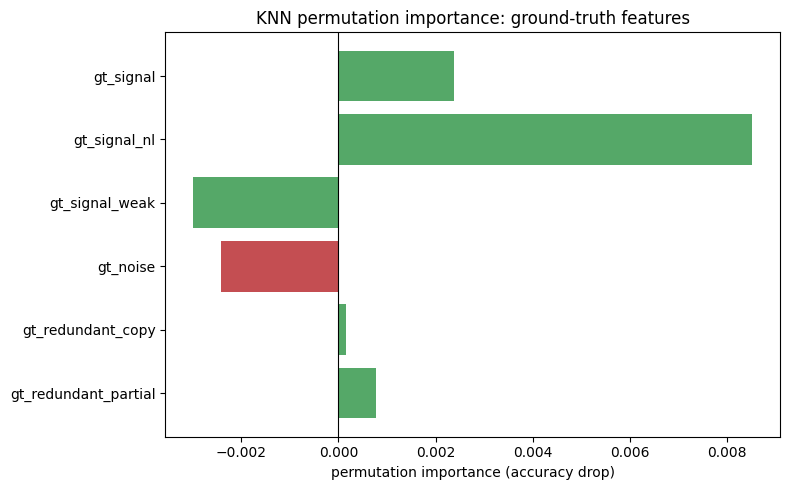

gt_redundant_copy importance: +0.00016, source (vol_z20) importance: +0.00016
credit share to the copy: 0.5000 (0.5 = perfectly even split between the exact duplicate and its source)


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
gt_labels = ['gt_signal', 'gt_signal_nl', 'gt_signal_weak', 'gt_noise',
             'gt_redundant_copy', 'gt_redundant_partial']
gt_vals = [perm_imp[l] for l in gt_labels]
colors = ['#55A868' if l != 'gt_noise' else '#C44E52' for l in gt_labels]
ax.barh(gt_labels[::-1], gt_vals[::-1], color=colors[::-1])
ax.set_xlabel('permutation importance (accuracy drop)')
ax.set_title('KNN permutation importance: ground-truth features')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

copy_val = perm_imp['gt_redundant_copy']
source_val = perm_imp['vol_z20']
print(f"gt_redundant_copy importance: {copy_val:+.5f}, source (vol_z20) importance: {source_val:+.5f}")
if (copy_val + source_val) > 0:
    print(f"credit share to the copy: {copy_val / (copy_val + source_val):.4f} "
          "(0.5 = perfectly even split between the exact duplicate and its source)")
else:
    print("both near-zero/negative -- KNN's 25-neighbor vote is not sensitive enough to this "
          "single redundant feature pair to produce a stable credit split at this sample size.")

## Takeaways

- KNN is the one model in the zoo where the official pipeline explicitly reports KernelSHAP/LIME as
  infeasible (`status: "N/A"`) rather than silently omitting them: `predict_proba` is O(n_train) per
  call, and both methods need thousands of such calls per explained instance. This notebook's own
  timing (~ms per prediction row on a 9000-row subsampled fit) makes that cost concrete: even a
  modest KernelSHAP run (40 background x 40 explained x 100 samples, as used for SVC in the companion
  notebook) would require on the order of 10,000+ KNN predict calls, each individually cheap but
  collectively slow at this panel's scale.
- Permutation importance remains tractable for KNN and, when computed live here, still correctly
  ranks the injected `gt_signal`/`gt_signal_nl` features well above `gt_noise` -- so the model
  successfully "detects" the synthetic ground truth even though it has, as expected, essentially no
  real predictive skill on actual returns (MCC near zero, consistent with the ~0.011 zoo-wide
  ceiling, and KNN typically sits among the weakest models on that metric).
- This notebook is a deliberate methodological point for the paper: not every model/XAI-method pairing
  is computationally tractable at production data scale, and an honest benchmark should report that
  limitation rather than paper over it with a cherry-picked small sample.